# Tutorial 16-3: Modern RL – "Proximal Policy Optimization (PPO)"

**Course:** CSEN 342: Deep Learning  
**Topic:** PPO, Clipped Surrogate Objective, and Stable Training

## Objective
Policy Gradient methods (like REINFORCE) are sensitive to the learning rate. If the step size is too large, the policy changes drastically, the agent falls off a "cliff" in performance, and it never recovers.

**Proximal Policy Optimization (PPO)** (Schulman et al., 2017) prevents this by enforcing a constraint: *"Do not change the policy too much in one step."*

It achieves this via the **Clipped Objective**:
$$ r_t(\theta) = \frac{\pi_\theta(a_t|s_t)}{\pi_{old}(a_t|s_t)} $$
$$ L^{CLIP} = \mathbb{E} [\min(r_t \hat{A}_t, \text{clip}(r_t, 1-\epsilon, 1+\epsilon)\hat{A}_t)] $$

In this tutorial, we will implement this state-of-the-art algorithm, which powers systems like OpenAI Five  and ChatGPT.

---

## Part 1: The Actor-Critic Network

PPO uses an Actor-Critic architecture similar to A2C. The Actor outputs probabilities (for the ratio $r_t$) and the Critic outputs values (for the advantage $\hat{A}_t$).

In [1]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Categorical
import numpy as np
import matplotlib.pyplot as plt

# Config
env_name = "CartPole-v1"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
lr = 3e-4
gamma = 0.99
eps_clip = 0.2        # Clipping parameter epsilon
K_epochs = 4          # Update policy for K epochs

class ActorCritic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(ActorCritic, self).__init__()
        self.fc1 = nn.Linear(state_dim, 64)
        self.fc2 = nn.Linear(64, 64)
        self.actor = nn.Linear(64, action_dim)
        self.critic = nn.Linear(64, 1)

    def forward(self, x):
        x = torch.tanh(self.fc1(x))
        x = torch.tanh(self.fc2(x))
        return x

    def act(self, state):
        # Convert numpy state to tensor if necessary
        if isinstance(state, np.ndarray):
            state = torch.from_numpy(state).float().to(device)
        
        x = self.forward(state)
        action_probs = F.softmax(self.actor(x), dim=-1)
        dist = Categorical(action_probs)
        action = dist.sample()
        action_logprob = dist.log_prob(action)
        
        return action.item(), action_logprob.item()
    
    def evaluate(self, state, action):
        x = self.forward(state)
        action_probs = F.softmax(self.actor(x), dim=-1)
        dist = Categorical(action_probs)
        
        action_logprobs = dist.log_prob(action)
        dist_entropy = dist.entropy()
        state_values = self.critic(x)
        
        return action_logprobs, state_values, dist_entropy

env = gym.make(env_name)
policy = ActorCritic(env.observation_space.shape[0], env.action_space.n).to(device)
optimizer = optim.Adam(policy.parameters(), lr=lr)
policy_old = ActorCritic(env.observation_space.shape[0], env.action_space.n).to(device)
policy_old.load_state_dict(policy.state_dict()) # Clone weights

print("PPO Models Initialized.")

PPO Models Initialized.


---

## Part 2: The Rollout Buffer

PPO collects a trajectory (or multiple trajectories) and stores them. Crucially, it stores the `log_prob` of the action *at the time it was taken*. This is $\pi_{old}$.

In [2]:
class RolloutBuffer:
    def __init__(self):
        self.actions = []
        self.states = []
        self.logprobs = []
        self.rewards = []
        self.is_terminals = []

    def clear(self):
        del self.actions[:]
        del self.states[:]
        del self.logprobs[:]
        del self.rewards[:]
        del self.is_terminals[:]

buffer = RolloutBuffer()

---

## Part 3: The PPO Update (The Core)

This is where the magic happens.

1.  **Calculate Advantages:** Monte Carlo estimate of returns.
2.  **Ratio:** Calculate $r_t = \frac{\pi_{new}}{\pi_{old}} = \exp(\log \pi_{new} - \log \pi_{old})$.
3.  **Surrogate Loss:** Compute both the unclipped `ratio * advantage` and the clipped `clamp(ratio) * advantage`.
4.  **Min:** Take the minimum (pessimistic bound).

In [3]:
def update():
    # 1. Monte Carlo Estimate of Returns
    rewards = []
    discounted_reward = 0
    for reward, is_terminal in zip(reversed(buffer.rewards), reversed(buffer.is_terminals)):
        if is_terminal:
            discounted_reward = 0
        discounted_reward = reward + (gamma * discounted_reward)
        rewards.insert(0, discounted_reward)
        
    rewards = torch.tensor(rewards, dtype=torch.float32).to(device)
    rewards = (rewards - rewards.mean()) / (rewards.std() + 1e-7)

    # Simplified tensor conversion (No incorrect squeezing)
    old_states = torch.stack(buffer.states).detach().to(device)
    old_actions = torch.stack(buffer.actions).detach().to(device)
    old_logprobs = torch.stack(buffer.logprobs).detach().to(device)
    
    for _ in range(K_epochs):
        logprobs, state_values, dist_entropy = policy.evaluate(old_states, old_actions)
        state_values = torch.squeeze(state_values)
        
        # Ratio calculation
        ratios = torch.exp(logprobs - old_logprobs)

        # Surrogate Loss calculation
        advantages = rewards - state_values.detach()   
        surr1 = ratios * advantages
        surr2 = torch.clamp(ratios, 1-eps_clip, 1+eps_clip) * advantages

        # PPO Loss: Actor + Critic - Entropy
        loss = -torch.min(surr1, surr2) + 0.5 * F.mse_loss(state_values, rewards) - 0.01 * dist_entropy

        optimizer.zero_grad()
        loss.mean().backward()
        optimizer.step()
        
    # Copy new weights to old policy
    policy_old.load_state_dict(policy.state_dict())
    buffer.clear()

---

## Part 4: The Training Loop

We collect data using `policy_old`, then update `policy` using PPO, then synchronize them.

In [4]:
max_episodes = 5000
update_timestep = 1000      # update policy every n timesteps

time_step = 0
scores = []

print("Starting PPO Training...")

for i_episode in range(1, max_episodes+1):
    state, _ = env.reset()
    current_ep_reward = 0
    
    for t in range(500): # Max steps per episode
        time_step += 1
        
        # 1. Interact with Env
        action, log_prob = policy_old.act(state)
        state_tensor = torch.FloatTensor(state).to(device)
        
        # 2. Store to Buffer
        buffer.states.append(state_tensor)
        buffer.actions.append(torch.tensor(action))
        buffer.logprobs.append(torch.tensor(log_prob))
        
        state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        
        buffer.rewards.append(reward)
        buffer.is_terminals.append(done)
        
        current_ep_reward += reward
        
        # 3. Update PPO Agent
        if time_step % update_timestep == 0:
            update()
            
        if done:
            break
            
    scores.append(current_ep_reward)
    
    if i_episode % 100 == 0:
        print(f"Episode {i_episode}\tAverage Score: {np.mean(scores[-20:]):.2f}")
        
    if np.mean(scores[-10:]) > 195:
        print(f"Solved at episode {i_episode}!")
        break

print("Training Complete.")

Starting PPO Training...
Episode 100	Average Score: 21.20
Episode 200	Average Score: 28.05
Episode 300	Average Score: 31.90
Episode 400	Average Score: 32.05
Episode 500	Average Score: 35.70
Episode 600	Average Score: 38.95
Episode 700	Average Score: 55.35
Episode 800	Average Score: 72.65
Episode 900	Average Score: 112.90
Episode 1000	Average Score: 190.95
Solved at episode 1000!
Training Complete.


### Visualization
PPO typically yields a very stable learning curve, monotonically increasing without the crashes seen in REINFORCE.

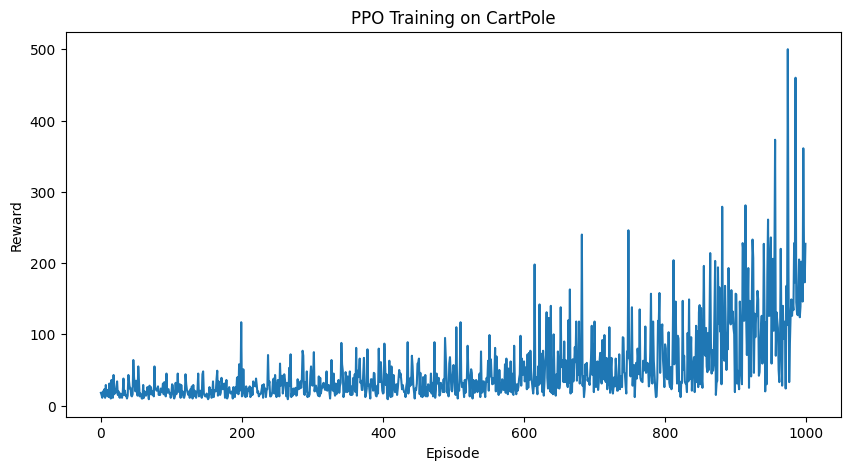

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(scores)
plt.title("PPO Training on CartPole")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.show()

And now we can visualize the outcome.

In [6]:
import os
import matplotlib.animation as animation
from IPython.display import HTML

# Setup for remote rendering
os.environ['XDG_RUNTIME_DIR'] = '/tmp/runtime-root'
os.makedirs(os.environ['XDG_RUNTIME_DIR'], exist_ok=True)
import matplotlib
matplotlib.use('Agg')

def visualize_simulation(env_name, model, device, max_steps=500):
    test_env = gym.make(env_name, render_mode="rgb_array")
    state, _ = test_env.reset()
    frames = []
    done = False
    steps = 0
    
    print("Simulating trained PPO policy...")
    while not done and steps < max_steps:
        frames.append(test_env.render())
        
        # Deterministic action selection for visualization (argmax)
        state_t = torch.tensor(state, dtype=torch.float32).to(device)
        with torch.no_grad():
            x = model.forward(state_t)
            action_probs = F.softmax(model.actor(x), dim=-1)
            action = torch.argmax(action_probs).item()
            
        state, reward, terminated, truncated, _ = test_env.step(action)
        done = terminated or truncated
        steps += 1
    
    test_env.close()
    
    # Create Animation
    fig = plt.figure(figsize=(6, 4))
    plt.axis('off')
    img = plt.imshow(frames[0])

    def animate(i):
        img.set_data(frames[i])
        return [img]

    anim = animation.FuncAnimation(fig, animate, frames=len(frames), interval=50, blit=True)
    plt.close() 
    return HTML(anim.to_jshtml())

# Run simulation
visualize_simulation("CartPole-v1", policy, device)

Simulating trained PPO policy...


### Conclusion

**Why PPO?**
1.  **Stability:** The clipping prevents the "destructive updates" common in RL.
2.  **Data Efficiency:** Unlike REINFORCE which uses a data point once, PPO re-uses the collected batch for `K_epochs`, squeezing more juice out of every interaction.

This is the algorithm used to fine-tune LLMs (RLHF). The "Environment" is the human ranker, and the "Action" is the generated text.